In [2]:
# import all the necessary libraries
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# The coupled van der pol oscillator system
# x1 = x[0]
# x1dot = x[1]
# x2 = x[2]
# x2dot = x[3]

def coupled_SHO(t,x,):
    return [x[1],
           -3.1 * x[0] + 1.6 * x[2],
           x[3],
           -1.4 * x[2] + 2.2 * x[0]]
    

In [4]:
# generate the data for testing
start = 0
end = 30
step = 0.01
t_span = [start, end]
x0 = [0.01, 0, 0.03, 0]
sol = solve_ivp(coupled_SHO, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [5]:
# The feature names
feature_names = ['x1', 'x1dot', 'x2', 'x2dot']

# Which feature library to use
# poly_lib = ps.PolynomialLibrary(degree=3)

# inputs_temp = np.tile([0, 1, 2, 3, 4], 1)
# inputs_per_library = np.reshape(inputs_temp, (1,4))

# inputs_per_library[0,2] = 1
# inputs_per_library[1,0] = 2
# inputs_per_library[1,1] = 2
# inputs_per_library[1,2] = 2
# print(inputs_per_library)

# generalized_library = ps.GeneralizedLibrary([poly_lib, fourier_lib],
#                                             inputs_per_library = inputs_per_library)



feature_library = ps.PolynomialLibrary(degree=1)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)


# Optimizer
opt = ps.STLSQ(threshold=0.01)
# opt = ps.SR3(threshold=0.1,thresholder="L0")
# opt = ps.FROLS(max_iter=5,alpha=0.5)
# opt = ps.SSR()
# opt = ps.STLSQ(threshold=0.1)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)


# Fitting the model to the training data
model.fit(x,
          t=t)

# Print the model
model.print()

model.get_feature_names()

(x1)' = 1.000 x1dot
(x1dot)' = -3.101 x1 + 1.601 x2
(x2)' = 1.000 x2dot
(x2dot)' = 2.201 x1 + -1.400 x2


['1', 'x1', 'x1dot', 'x2', 'x2dot']

In [6]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

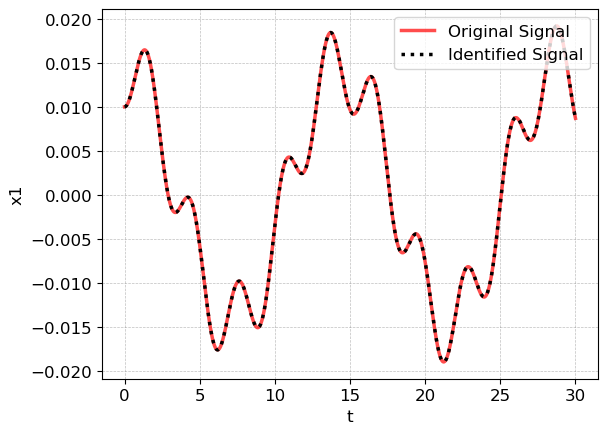

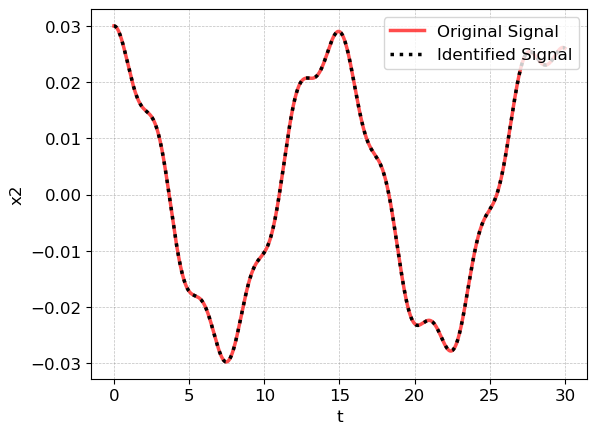

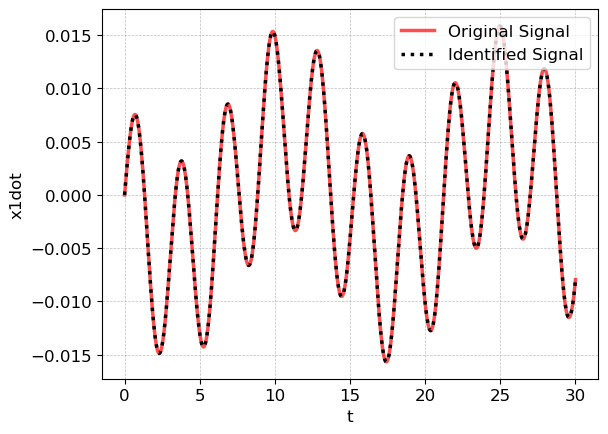

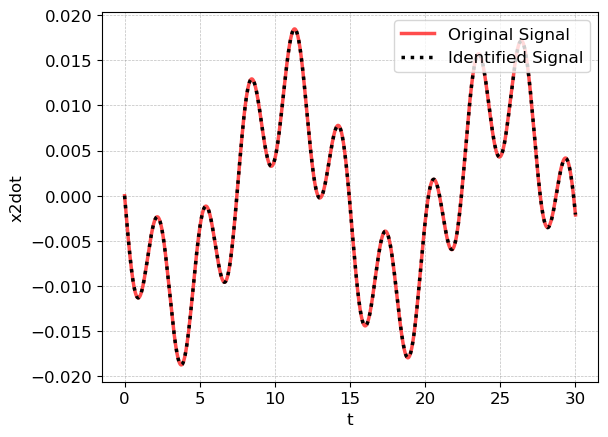

In [7]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# x1
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x1")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x1_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()

# x2
plt.plot(t,x[:,2],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,2],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x2")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x2_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()


# x1 dot
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x1dot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x1dot_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()

# x2 dot
plt.plot(t,x[:,3],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,3],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x2dot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x2dot_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()

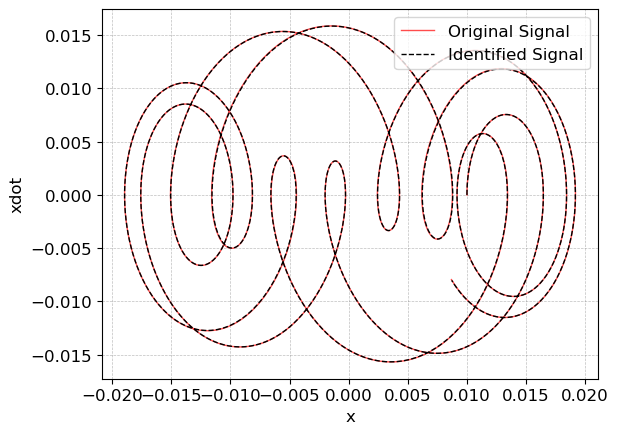

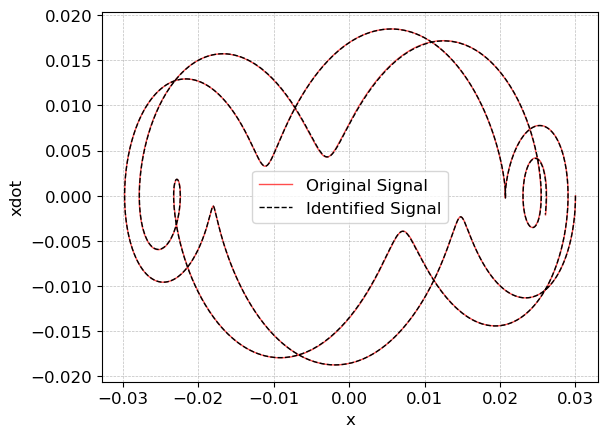

In [8]:
# Phase Portrait Oscillator 1
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=1, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=1,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()

# Phase Portrait Oscillator 2
plt.plot(x[:,2],x[:,3],'r',alpha=0.7,linewidth=1, label="Original Signal")
plt.plot(sim[:,2],sim[:,3],'k--',linewidth=1,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_coupled_SHO.pdf', format='pdf', dpi=300)
plt.show()

In [9]:
# Metrics
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.9999973388699691
Mean Squared Error: 3.225679580239334e-10
